In [ ]:
pip install Bio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.3/321.3 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 54.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 3.9 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Bio import Entrez, SeqIO
from collections import defaultdict

№1

Вручную постройте матрицу Нидлмана-Вунша для строк X: ATGCCG и Y : ATCG.
Параметры: Match = +3, Mismatch = −3, Gap = −2.
Укажите итоговый Score, матрицу и само выравнивание.

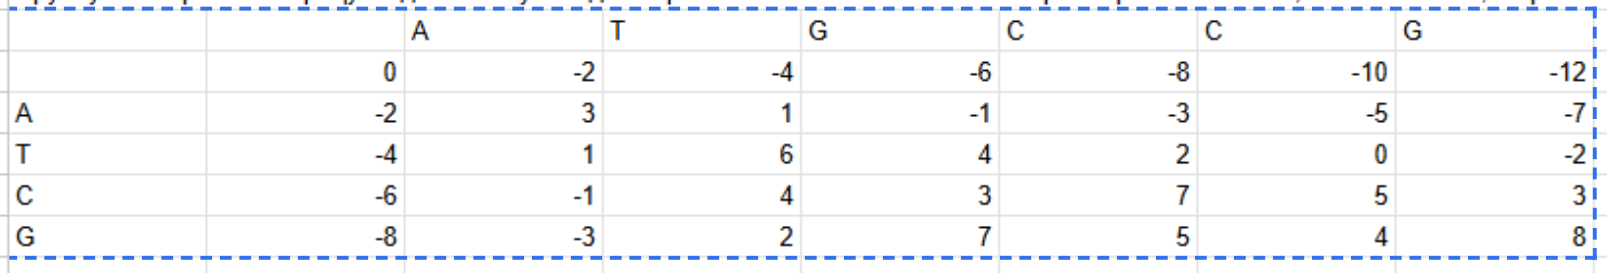

score=8

ATGCCG

AT--CG

№2

Для тех же строк и параметров постройте матрицу Смита-Ватермана.
Укажите итоговый Score, матрицу и само выравнивание.


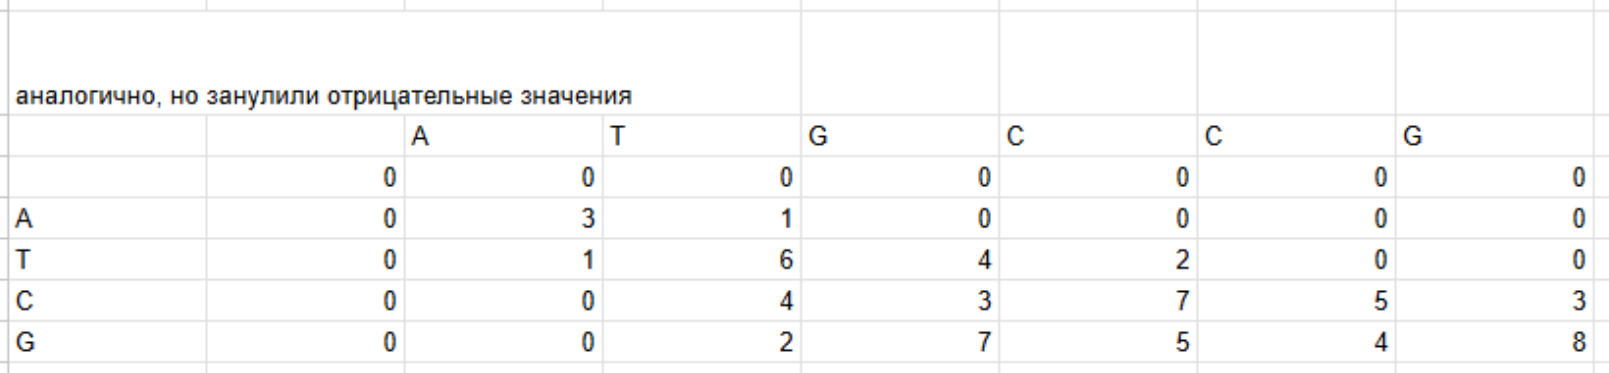

score=8

ATGCCG

AT--CG

№3

Реализуйте алгоритм Нидлмана-Вунша на python и рассчитайте Score для выравнивания ATGCAGCAGCAGCCA
и ATATAT при двух моделях:

• Линейный штраф: Gap = −4

• Аффинный штраф: Открытие гэпа (Open) = −10, продолжение гэпа (Extend) = −1.

Объясните, какую биологическую особенность лучше описывает аффинная модель. Приложите матрицы
и выравнивания.

In [ ]:
a = "ATGCAGCAGCAGCCA"
b = "ATATAT"

#линейный штраф
def nw(a, b, match=3, mismatch=-3, gap=-4):
    x, y = len(a), len(b)
    f = np.zeros((x+1, y+1))
    for i in range(x+1): f[i][0] = i * gap
    for j in range(y+1): f[0][j] = j * gap
    for i in range(1, x+1):
        for j in range(1, y+1):
            s = match if a[i-1] == b[j-1] else mismatch
            f[i][j] = max(f[i-1][j-1]+s, f[i-1][j]+gap, f[i][j-1]+gap)
    return f

#выравнивание
def tb(f, a, b, match=3, mismatch=-3, gap=-4):
    x, y = len(a), len(b)
    ra, rb = '', ''
    while x > 0 or y > 0:
        s = match if (x>0 and y>0 and a[x-1]==b[y-1]) else mismatch
        if x>0 and y>0 and f[x][y] == f[x-1][y-1]+s:
            ra, rb = a[x-1]+ra, b[y-1]+rb; x -= 1; y -= 1
        elif x>0 and f[x][y] == f[x-1][y]+gap:
            ra, rb = a[x-1]+ra, '-'+rb; x -= 1
        else:
            ra, rb = '-'+ra, b[y-1]+rb; y -= 1
    return ra, rb


fl = nw(a, b)
print(pd.DataFrame(fl, index=['']+list(a), columns=['']+list(b)).to_string())
print(f"score = {fl[len(a)][len(b)]}")

ra_l, rb_l = tb(fl, a, b)
print(f"a: {ra_l}")
print(f"b: {rb_l}")




NEG = float('-inf')
#аффинный штраф
def nw_aff(a, b, match=3, mismatch=-3, gap_open=-10, gap_ext=-1):
    x, y = len(a), len(b)
    M  = np.full((x+1, y+1), NEG)
    Ix = np.full((x+1, y+1), NEG)
    Iy = np.full((x+1, y+1), NEG)
    M[0][0] = 0
    for x in range(1, x+1): Ix[x][0] = gap_open + x * gap_ext
    for y in range(1, y+1): Iy[0][y] = gap_open + y * gap_ext
    ptr = np.full((x+1, y+1), '', dtype=object)
    for x in range(1, x+1):
        for y in range(1, y+1):
            s = match if a[x-1] == b[y-1] else mismatch
            M[x][y]  = max(M[x-1][y-1], Ix[x-1][y-1], Iy[x-1][y-1]) + s
            Ix[x][y] = max(M[x-1][y] + gap_open + gap_ext, Ix[x-1][y] + gap_ext)
            Iy[x][y] = max(M[x][y-1] + gap_open + gap_ext, Iy[x][y-1] + gap_ext)
    score = max(M[x][y], Ix[x][y], Iy[x][y])
    return score, M, Ix, Iy

#выравнивание
def tb_aff(M, Ix, Iy, a, b, match=3, mismatch=-3, gap_open=-10, gap_ext=-1):
    x, y = len(a), len(b)
    ra, rb = '', ''
    cur = max([('M', M[x][y]), ('Ix', Ix[x][y]), ('Iy', Iy[x][y])], key=lambda x: x[1])[0]
    while x > 0 or y > 0:
        if cur == 'M':
            s = match if a[x-1] == b[y-1] else mismatch
            ra, rb = a[x-1]+ra, b[y-1]+rb
            best = max([('M', M[x-1][y-1]), ('Ix', Ix[x-1][y-1]), ('Iy', Iy[x-1][y-1])], key=lambda x: x[1])[0]
            cur = best; x -= 1; y -= 1
        elif cur == 'Ix':
            ra, rb = a[x-1]+ra, '-'+rb
            cur = 'M' if M[x-1][y]+gap_open+gap_ext >= Ix[x-1][y]+gap_ext else 'Ix'
            x -= 1
        else:
            ra, rb = '-'+ra, b[y-1]+rb
            cur = 'M' if M[x][y-1]+gap_open+gap_ext >= Iy[x][y-1]+gap_ext else 'Iy'
            y -= 1
    return ra, rb


score_a, M_a, Ix_a, Iy_a = nw_affine(a, b)
print("с аффинным штрафом")
print(f"score = {score_a}")

ra_a, rb_a = traceback_affine(M_a, Ix_a, Iy_a, a, b)
print(f"a: {ra_a}")
print(f"b: {rb_a}")

            A     T     A     T     A     T
    0.0  -4.0  -8.0 -12.0 -16.0 -20.0 -24.0
A  -4.0   3.0  -1.0  -5.0  -9.0 -13.0 -17.0
T  -8.0  -1.0   6.0   2.0  -2.0  -6.0 -10.0
G -12.0  -5.0   2.0   3.0  -1.0  -5.0  -9.0
C -16.0  -9.0  -2.0  -1.0   0.0  -4.0  -8.0
A -20.0 -13.0  -6.0   1.0  -3.0   3.0  -1.0
G -24.0 -17.0 -10.0  -3.0  -2.0  -1.0   0.0
C -28.0 -21.0 -14.0  -7.0  -6.0  -5.0  -4.0
A -32.0 -25.0 -18.0 -11.0 -10.0  -3.0  -7.0
G -36.0 -29.0 -22.0 -15.0 -14.0  -7.0  -6.0
C -40.0 -33.0 -26.0 -19.0 -18.0 -11.0 -10.0
A -44.0 -37.0 -30.0 -23.0 -22.0 -15.0 -14.0
G -48.0 -41.0 -34.0 -27.0 -26.0 -19.0 -18.0
C -52.0 -45.0 -38.0 -31.0 -30.0 -23.0 -22.0
C -56.0 -49.0 -42.0 -35.0 -34.0 -27.0 -26.0
A -60.0 -53.0 -46.0 -39.0 -38.0 -31.0 -30.0
score = -30.0
a: ATGCAGCAGCAGCCA
b: AT-----A-TA---T
с аффинным штрафом
score = -19.0
a: ATGCAGCAGCAGCCA
b: ATATA---------T


В линейном штрафе очень много отдельных гэпов, а в аффинном штрафуется за начало гэпа сильнее, чем за продолжение, за счет чего модель становится более реалистичной (тк вероятнее потерять какой-то фрагмент, чем несколько отдельных нуклеотидов)

№4

Seed-and-Extend — двухфазный эвристический алгоритм для поиска локального выравнивания, который
заменяет полное вычисление матрицы Смита–Уотермана за O(n × m) на приближённое решение, работающее значительно быстрее на практике.

Входные данные:

• Запрос (query): Q = q1q2 . . . qm

• База данных (database): D = d1d2 . . . dn, где n ≫ m

• Индекс БД: Создать словарь и разбить D на k-меры длиной k, и для каждого вхождения в геном
этого k-мера добавить в словарь {ki = [coord1, . . . , coordn]}.

• Параметры: длина seed k, штрафы за match/mismatch/gap, порог X-drop X.

Практическое задание:

Реализуйте этот алгоритм и проверьте его на последовательностях:

• Референс: CTAGGATCCAGGCATACGA

• Последовательность для поиска: GGATCCATTCATTA

В качестве ответа на задание нужно приложить k-мер, который дал лучшее выравнивание, Индекс БД,
итоговый Smax, Scur для всех расширений k-меров в каждую сторону, последовательности, расширенные
в обе стороны, и итоговое выравнивание.

Параметры: k = 4, X = 2.


In [ ]:
ref = "CTAGGATCCAGGCATACGA"
query = "GGATCCATTCATTA"
k, X  = 4, 2
match, mismatch = 2, -2

def index_bd(db, k):
    idx = {}
    for i in range(len(db)-k+1):
        km = db[i:i+k]
        idx.setdefault(km, []).append(i)
    return idx

index = index_bd(ref, k)
print("индекс бд:", index)

#для пары символов
def score_pair(a, b):
    return match if a == b else mismatch

#расшираение сида
def extend(query, ref, qi, ri, seed_score, X, direction=1):
    scur = seed_score
    smax = seed_score
    best_qi, best_ri = qi, ri
    history = []
    while 0 <= qi < len(query) and 0 <= ri < len(ref):
        scur += score_pair(query[qi], ref[ri])
        history.append((qi, ri, scur))
        if scur > smax:
            smax = scur
            best_qi, best_ri = qi + (1 if direction == 1 else 0), ri + (1 if direction == 1 else 0)
        if smax - scur >= X:
            break
        qi += direction
        ri += direction
    return smax, best_qi, best_ri, history

seeds = []
for qi in range(len(query)-k+1):
    km = query[qi:qi+k]
    if km in db_index:
        for ri in db_index[km]:
            seeds.append((qi, ri, km))

print(f"\nсиды: {seeds}")

best_result = None
best_smax = -999

for (qi, ri, km) in seeds:
    seed_score = k * match
    smax_l, lq, lr, hist_l = extend(query, ref, qi-1, ri-1, seed_score, X, direction=-1)
    smax_r, rq, rr, hist_r = extend(query, ref, qi+k, ri+k, smax_l, X, direction=1)

    print(f"\nseed '{km}' q={qi} r={ri}")
    print(f"seed_score = {seed_score}")
    print(f"расширение влево {hist_l}")
    print(f"smax {smax_l}, левая граница q={lq} r={lr}")
    print(f"расширение вправо: {hist_r}")
    print(f"финальный smax {smax_r}, правая граница q={rq} r={rr}")

    if smax_r > best_smax:
        best_smax = smax_r
        best_result = (qi, ri, km, lq, lr, rq, rr, smax_l, smax_r, hist_l, hist_r)

qi, ri, km, lq, lr, rq, rr, smax_l, smax_r, hl, hr = best_result
print(f"\nлучший сид '{km}'")
print(f"smax в итоге {best_smax}")

print(f"выравнивание:")
start_q = lq + 1
start_r = lr + 1
print(f"query[{start_q}:{rq}] = {query[start_q:rq]}")
print(f"ref[{start_r}:{rr}] = {ref[start_r:rr]}")

индекс бд: {'CTAG': [0], 'TAGG': [1], 'AGGA': [2], 'GGAT': [3], 'GATC': [4], 'ATCC': [5], 'TCCA': [6], 'CCAG': [7], 'CAGG': [8], 'AGGC': [9], 'GGCA': [10], 'GCAT': [11], 'CATA': [12], 'ATAC': [13], 'TACG': [14], 'ACGA': [15]}

сиды: [(0, 3, 'GGAT'), (1, 4, 'GATC'), (2, 5, 'ATCC'), (3, 6, 'TCCA')]

seed 'GGAT' q=0 r=3
seed_score = 8
расширение влево []
smax 8, левая граница q=-1 r=2
расширение вправо: [(4, 7, 10), (5, 8, 12), (6, 9, 14), (7, 10, 12)]
финальный smax 14, правая граница q=7 r=10

seed 'GATC' q=1 r=4
seed_score = 8
расширение влево [(0, 3, 10)]
smax 10, левая граница q=0 r=3
расширение вправо: [(5, 8, 12), (6, 9, 14), (7, 10, 12)]
финальный smax 14, правая граница q=7 r=10

seed 'ATCC' q=2 r=5
seed_score = 8
расширение влево [(1, 4, 10), (0, 3, 12)]
smax 12, левая граница q=0 r=3
расширение вправо: [(6, 9, 14), (7, 10, 12)]
финальный smax 14, правая граница q=7 r=10

seed 'TCCA' q=3 r=6
seed_score = 8
расширение влево [(2, 5, 10), (1, 4, 12), (0, 3, 14)]
smax 14, левая гран

В общем, мы получили совпадающий фрагмент у обоих последовательностей (GGATCCA)

№5

Постройте DotPlot график синтении (выравнивания) между митохондриальным геномом неандертальца
и митохондриальным геномом современного человека.

Последовательности для анализа:

• Митохондрия неандертальца (NC_011137.1):
https://www.ncbi.nlm.nih.gov/nucleotide/NC_011137.1

• Митохондрия современного человека (NC_012920.1):
https://www.ncbi.nlm.nih.gov/nuccore/NC_012920.1

Задание:

1. Скачайте обе последовательности в формате FASTA.

2. Напишите собственный скрипт на Python с использованием библиотек Biopython/Matplotlib для
построения точечного графика (DotPlot).

3. Приложите полученный график к вашему ответу.

4. Проанализируйте полученный график: наблюдаются ли крупные структурные перестройки (инверсии, крупные делеции или дупликации) между митохондриальными геномами человека и неандертальца? Сделайте краткий вывод (2-3 предложения).


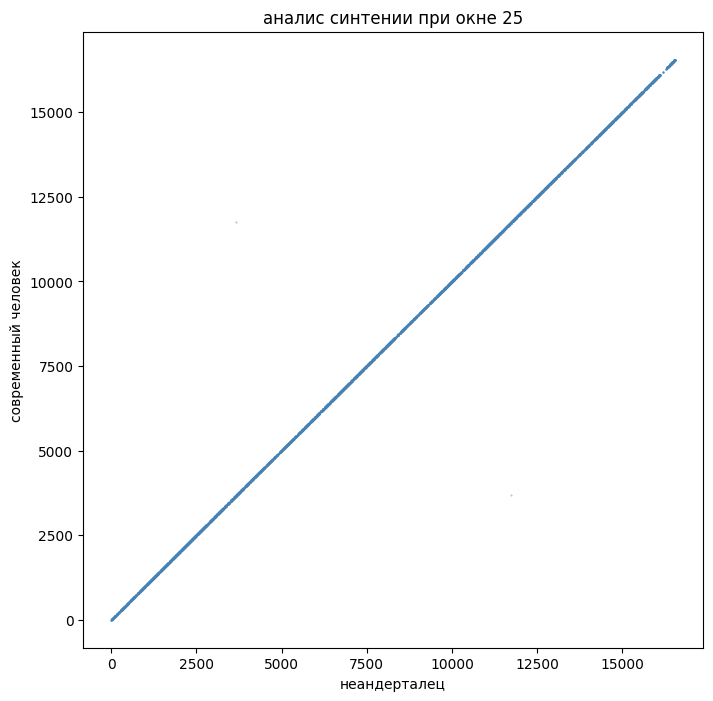

In [ ]:
seq1 = str(SeqIO.read("sequence.fasta", "fasta").seq).upper()
seq2 = str(SeqIO.read("sequence (1).fasta", "fasta").seq).upper()

k = 15
index = defaultdict(list)
for i in range(len(seq1)-k+1):
    index[seq1[i:i+k]].append(i)

x, y = [], []
for j in range(len(seq2)-k+1):
    km = seq2[j:j+k]
    if km in index:
        for i in index[km]:
            x.append(i)
            y.append(j)

plt.figure(figsize=(8,8))
plt.scatter(x, y, s=0.2, c='steelblue', alpha=0.5)
plt.xlabel("неандерталец")
plt.ylabel("современный человек")
plt.title("аналис синтении при окне 25")
plt.show()